# Radios dataset

## Download
We need to download it from [https://northeurope1-mediap.svc.ms/transform/zip?cs=fFNQTw](https://northeurope1-mediap.svc.ms/transform/zip?cs=fFNQTw), as including it in version control would be to expensive.

In [20]:
import os

# Define the expected directories
expected_dirs = [
    'test/NORMAL', 'test/PNEUMONIA',
    'train/NORMAL', 'train/PNEUMONIA',
    'val/NORMAL', 'val/PNEUMONIA'
]

# Check if the dataset structure is already present
all_dirs_exist = all(os.path.isdir(dir) for dir in expected_dirs)

if all_dirs_exist:
    print("✅ Dataset is already in place with the correct structure.")
else:
    print("❌ Dataset structure incomplete. Download it from https://northeurope1-mediap.svc.ms/transform/zip?cs=fFNQTw")

✅ Dataset is already in place with the correct structure.


## Structure

The dataset features only images, it's already split in test, train, and evaluation parts, and file names communicate information on the type of pneumonia. Let's check out what kind of data we're working with.

In [21]:
from prettytable import PrettyTable
from glob import glob

# Initialize a table to display the results
table = PrettyTable()
table.field_names = ["Set", "NORMAL", "PNEUMONIA (Bacteria)", "PNEUMONIA (Virus)", "Total"]

# Define the sets to check
sets = ["test", "train", "val"]

# Iterate through each set and count the images
for dataset in sets:
    normal_count = len(glob(f"{dataset}/NORMAL/**/*", recursive=True))
    pneumonia_bacteria_count = len(glob(f"{dataset}/PNEUMONIA/*bacteria*", recursive=True))
    pneumonia_virus_count = len(glob(f"{dataset}/PNEUMONIA/*virus*", recursive=True))
    total_count = normal_count + pneumonia_bacteria_count + pneumonia_virus_count
    
    # Add the counts to the table
    table.add_row([dataset.capitalize(), normal_count, pneumonia_bacteria_count, pneumonia_virus_count, total_count])

# Display the table
print(table)

+-------+--------+----------------------+-------------------+-------+
|  Set  | NORMAL | PNEUMONIA (Bacteria) | PNEUMONIA (Virus) | Total |
+-------+--------+----------------------+-------------------+-------+
|  Test |  234   |         242          |        148        |  624  |
| Train |  1341  |         2530         |        1345       |  5216 |
|  Val  |   8    |          8           |         0         |   16  |
+-------+--------+----------------------+-------------------+-------+


In [28]:
from PIL import Image
import matplotlib.pyplot as plt
from glob import glob

# Helper function to display images
def display_images(image_paths, titles, cols=3):
    rows = (len(image_paths) + cols - 1) // cols
    _, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i, (img_path, title) in enumerate(zip(image_paths, titles)):
        img = Image.open(img_path).convert('L')  # L = luminance (grayscale)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(title)
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

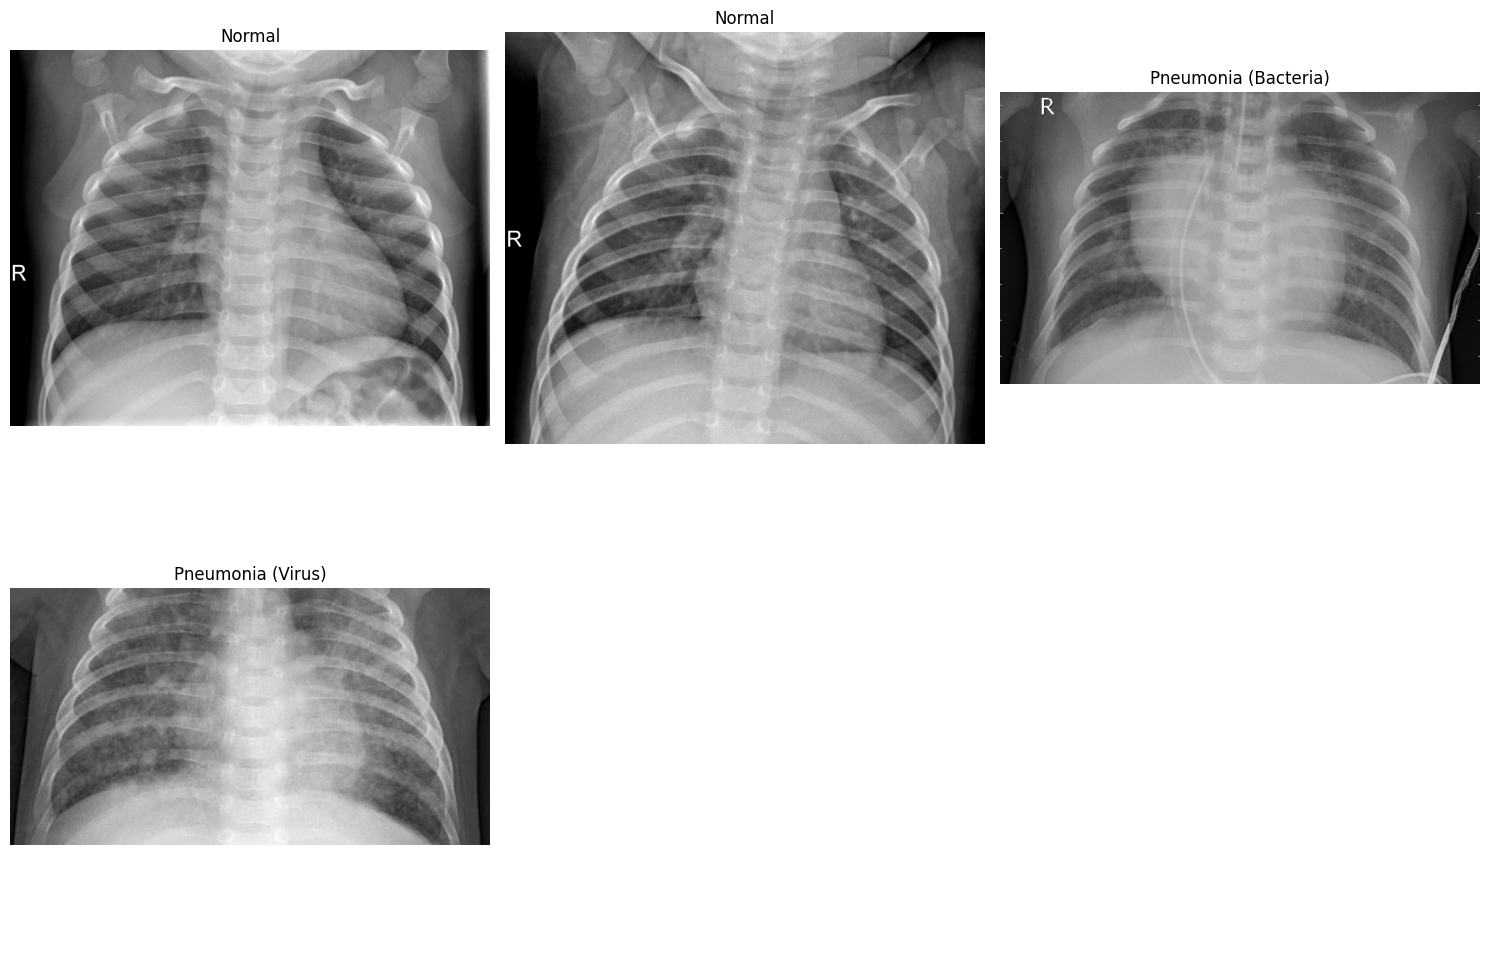

In [29]:
normal_images = glob("train/NORMAL/*")[:2]
pneumonia_bacteria_images = glob("train/PNEUMONIA/*bacteria*")[:1]
pneumonia_virus_images = glob("train/PNEUMONIA/*virus*")[:1]

# Combine the images and titles
image_paths = normal_images + pneumonia_bacteria_images + pneumonia_virus_images
titles = ["Normal"] * len(normal_images) + ["Pneumonia (Bacteria)"] * len(pneumonia_bacteria_images) + ["Pneumonia (Virus)"] * len(pneumonia_virus_images)

# Display the images
display_images(image_paths, titles)

Dimensions some to vary. Let's investigate.

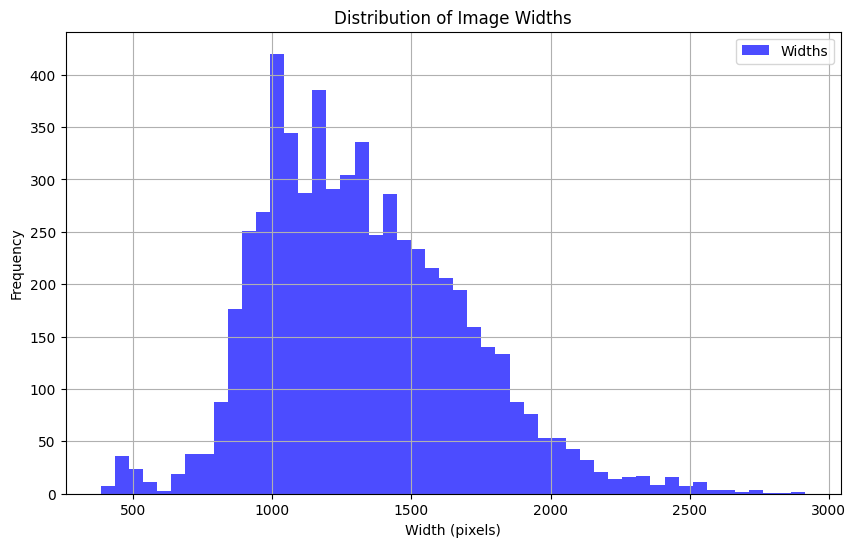

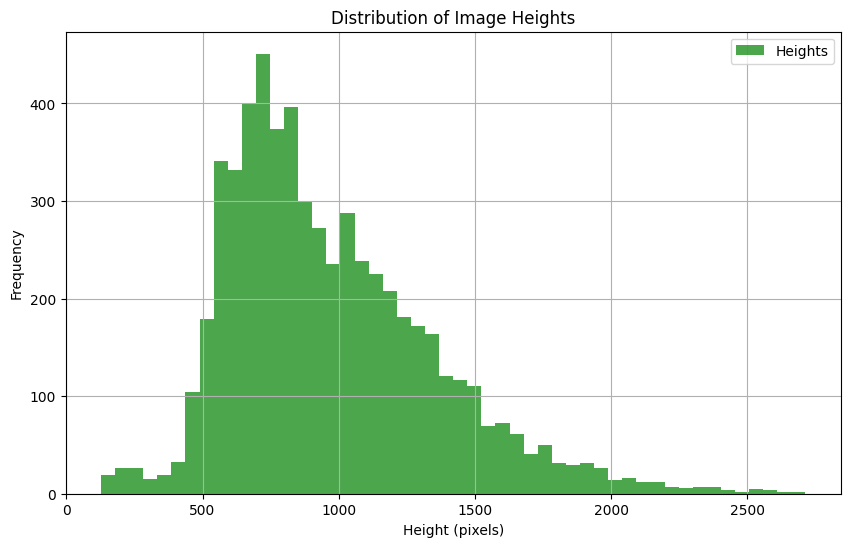

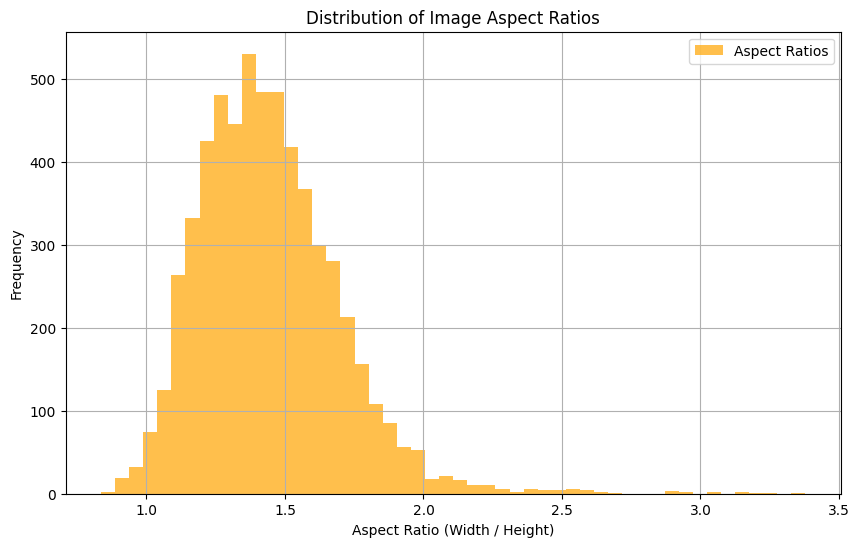

In [24]:
# Get all .jpeg and .jpg files in the folder recursively
all_image_paths = glob("**/*.jpeg", recursive=True) + glob("**/*.jpg", recursive=True)

# Analyze the whole dataset recursively
widths = []
heights = []

for img_path in all_image_paths:
    with Image.open(img_path) as img:
        widths.append(img.width)
        heights.append(img.height)

# Calculate aspect ratios
aspect_ratios = [w / h for w, h in zip(widths, heights)]

# Plot histogram for widths
plt.figure(figsize=(10, 6))
plt.hist(widths, bins=50, color='blue', alpha=0.7, label='Widths')
plt.title('Distribution of Image Widths')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram for heights
plt.figure(figsize=(10, 6))
plt.hist(heights, bins=50, color='green', alpha=0.7, label='Heights')
plt.title('Distribution of Image Heights')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram for aspect ratios
plt.figure(figsize=(10, 6))
plt.hist(aspect_ratios, bins=50, color='orange', alpha=0.7, label='Aspect Ratios')
plt.title('Distribution of Image Aspect Ratios')
plt.xlabel('Aspect Ratio (Width / Height)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


We can see that image sizes vary widely, and we might need to remove some items from the dataset before moving on, as well as resizing all the images to a smaller dimension.

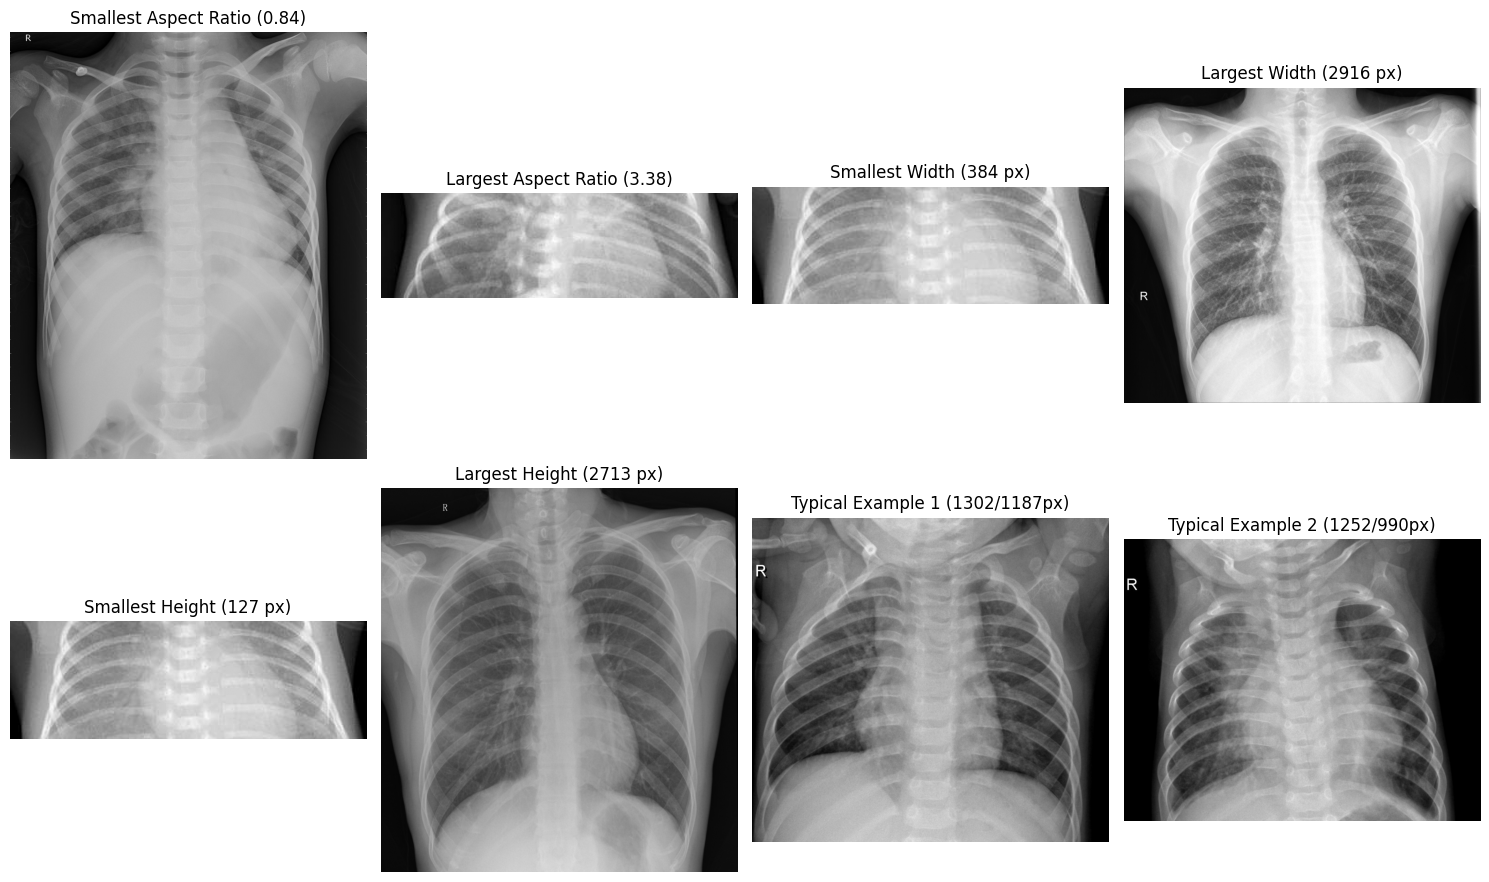

In [30]:
# Find indices of images with the smallest and largest widths and heights
max_aspect_ratio_index = aspect_ratios.index(max(aspect_ratios))
min_aspect_ratio_index = aspect_ratios.index(min(aspect_ratios))
min_width_index = widths.index(min(widths))
max_width_index = widths.index(max(widths))
min_height_index = heights.index(min(heights))
max_height_index = heights.index(max(heights))

# Select a couple of "normal" examples (middle aspect ratios)
normal_example_indices = [len(aspect_ratios) // 3, 2 * len(aspect_ratios) // 3]

# Get the corresponding image paths and titles
extreme_image_paths = [
    all_image_paths[min_aspect_ratio_index],
    all_image_paths[max_aspect_ratio_index],
    all_image_paths[min_width_index],
    all_image_paths[max_width_index],
    all_image_paths[min_height_index],
    all_image_paths[max_height_index],
    all_image_paths[normal_example_indices[0]],
    all_image_paths[normal_example_indices[1]],
]
extreme_titles = [
    f"Smallest Aspect Ratio ({min(aspect_ratios):.2f})",
    f"Largest Aspect Ratio ({max(aspect_ratios):.2f})",
    f"Smallest Width ({min(widths)} px)",
    f"Largest Width ({max(widths)} px)",
    f"Smallest Height ({min(heights)} px)",
    f"Largest Height ({max(heights)} px)",
    f"Typical Example 1 ({widths[normal_example_indices[0]]}/{heights[normal_example_indices[0]]}px)",
    f"Typical Example 2 ({widths[normal_example_indices[1]]}/{heights[normal_example_indices[1]]}px)",
]

# Display the images in an expressive layout
display_images(extreme_image_paths, extreme_titles, cols=4)